**Smart Energy Consumption Prediction**
*  Data loading
*  Preprocessing
*  EDA
*  ML models
*  Evaluation
*  SHAP interpretation
*  Simulation (peak load optimization)

In [ ]:
!pip install shap xgboost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import shap

In [ ]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    parse_dates={'datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    low_memory=False,
    na_values=['?']
)

/tmp/ipykernel_8084/2946683525.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipykernel_8084/2946683525.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
/tmp/ipykernel_8084/2946683525.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


In [ ]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False,
    na_values=['?']
)

# Combine Date and Time manually (NEW METHOD)
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True   # IMPORTANT FIX
)

# Drop old columns
df.drop(['Date', 'Time'], axis=1, inplace=True)

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360666 entries, 0 to 360665
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Global_active_power    356739 non-null  float64       
 1   Global_reactive_power  356739 non-null  float64       
 2   Voltage                356739 non-null  float64       
 3   Global_intensity       356739 non-null  float64       
 4   Sub_metering_1         356739 non-null  float64       
 5   Sub_metering_2         356739 non-null  float64       
 6   Sub_metering_3         356738 non-null  float64       
 7   datetime               360666 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(7)
memory usage: 22.0 MB
None


In [ ]:
df

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00
...,...,...,...,...,...,...,...,...
360661,0.228,0.136,241.99,1.0,0.0,0.0,0.0,2007-08-24 04:25:00
360662,0.232,0.136,242.06,1.2,0.0,0.0,0.0,2007-08-24 04:26:00
360663,0.202,0.112,241.94,1.0,0.0,0.0,0.0,2007-08-24 04:27:00
360664,0.114,0.000,241.91,0.6,0.0,0.0,0.0,2007-08-24 04:28:00


Data Cleaning

In [ ]:
df = df.dropna()

# Convert to float
for col in df.columns:
    if col != 'datetime':
        df[col] = df[col].astype(float)

# Feature Engineering
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month

/tmp/ipykernel_8084/1767952895.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(float)
/tmp/ipykernel_8084/1767952895.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(float)
/tmp/ipykernel_8084/1767952895.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

In [ ]:
print(df.describe())

       Global_active_power  Global_reactive_power        Voltage  \
count        323987.000000          323987.000000  323987.000000   
mean              1.145673               0.124703     239.142861   
min               0.082000               0.000000     223.490000   
25%               0.286000               0.000000     236.470000   
50%               0.514000               0.106000     239.540000   
75%               1.592000               0.196000     241.790000   
max              10.670000               1.148000     251.700000   
std               1.186947               0.112201       3.705911   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
count     323987.000000   323987.000000   323987.000000   323987.000000   
mean           4.899492        1.276138        1.646896        5.614747   
min            0.400000        0.000000        0.000000        0.000000   
25%            1.200000        0.000000        0.000000        0.000000   
50%         

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 356738 entries, 0 to 360664
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Global_active_power    356738 non-null  float64       
 1   Global_reactive_power  356738 non-null  float64       
 2   Voltage                356738 non-null  float64       
 3   Global_intensity       356738 non-null  float64       
 4   Sub_metering_1         356738 non-null  float64       
 5   Sub_metering_2         356738 non-null  float64       
 6   Sub_metering_3         356738 non-null  float64       
 7   datetime               356738 non-null  datetime64[ns]
 8   hour                   356738 non-null  int32         
 9   day                    356738 non-null  int32         
 10  month                  356738 non-null  int32         
dtypes: datetime64[ns](1), float64(7), int32(3)
memory usage: 28.6 MB
None


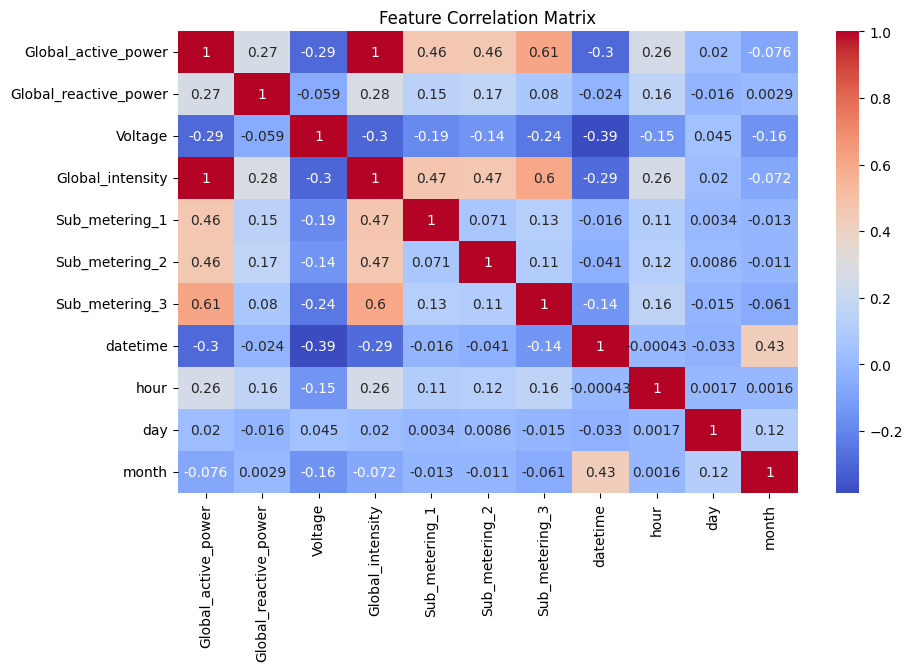

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
import statsmodels.api as sm

# Define features and target
features = ['Voltage', 'Global_intensity', 'Sub_metering_1',
            'Sub_metering_2', 'Sub_metering_3', 'hour', 'day', 'month']

X = df[features]
y = df['Global_active_power']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Model level stats
f_stat = model.fvalue
f_pvalue = model.f_pvalue

print("F-statistic:", f_stat)
print("F-test p-value:", f_pvalue)

results_table = pd.DataFrame({
    "Feature": model.params.index,
    "Coefficient": model.params.values,
    "F-statistic": f_stat,
    "P-Value": model.pvalues.values
})

print(results_table)

F-statistic: 25278099.7230306
F-test p-value: 0.0
            Feature  Coefficient   F-statistic        P-Value
0             const    -0.937008  2.527810e+07   0.000000e+00
1           Voltage     0.003840  2.527810e+07   0.000000e+00
2  Global_intensity     0.235871  2.527810e+07   0.000000e+00
3    Sub_metering_1    -0.000557  2.527810e+07  1.200743e-283
4    Sub_metering_2    -0.000725  2.527810e+07   0.000000e+00
5    Sub_metering_3     0.002360  2.527810e+07   0.000000e+00
6              hour    -0.000009  2.527810e+07   4.408397e-01
7               day     0.000064  2.527810e+07   2.227922e-11
8             month    -0.000686  2.527810e+07  6.185570e-118


In [ ]:
from IPython.display import display

display(results_table)

,Feature,Coefficient,F-statistic,P-Value
0,const,-0.937008,2.527810e+07,0.000000e+00
1,Voltage,0.003840,2.527810e+07,0.000000e+00
2,Global_intensity,0.235871,2.527810e+07,0.000000e+00
3,Sub_metering_1,-0.000557,2.527810e+07,1.200743e-283
4,Sub_metering_2,-0.000725,2.527810e+07,0.000000e+00
5,Sub_metering_3,0.002360,2.527810e+07,0.000000e+00
6,hour,-0.000009,2.527810e+07,4.408397e-01
7,day,0.000064,2.527810e+07,2.227922e-11
8,month,-0.000686,2.527810e+07,6.185570e-118


In [ ]:
from scipy.stats import pearsonr
import pandas as pd

results = []

for col in features:
    corr, p = pearsonr(df[col], df['Global_active_power'])
    results.append([col, corr, p])

results_df = pd.DataFrame(results, columns=['Feature', 'Correlation', 'p-value'])

print(results_df)

            Feature  Correlation       p-value
0           Voltage    -0.293676  0.000000e+00
1  Global_intensity     0.998943  0.000000e+00
2    Sub_metering_1     0.464924  0.000000e+00
3    Sub_metering_2     0.460558  0.000000e+00
4    Sub_metering_3     0.612927  0.000000e+00
5              hour     0.260332  0.000000e+00
6               day     0.020487  1.953975e-34
7             month    -0.075990  0.000000e+00


EDA : Exploratory Data Analysis (Visualization)

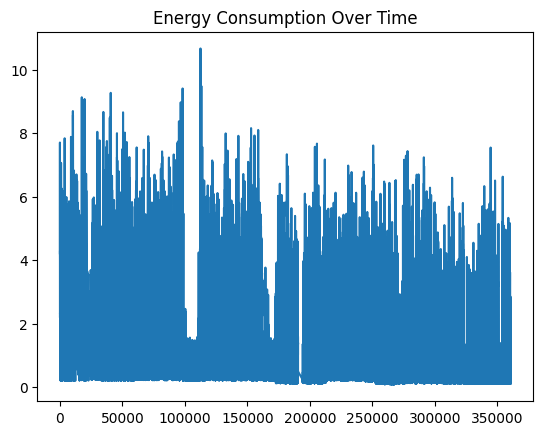

In [ ]:
plt.figure()
df['Global_active_power'].plot(title="Energy Consumption Over Time")
plt.show()

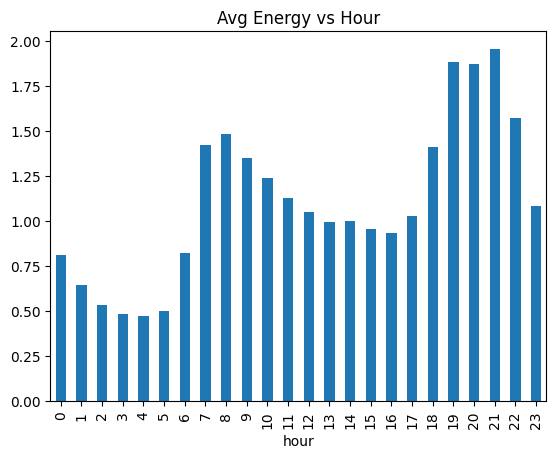

In [ ]:
plt.figure()
df.groupby('hour')['Global_active_power'].mean().plot(kind='bar', title="Avg Energy vs Hour")
plt.show()

Feature Selection

In [ ]:
features = ['Voltage', 'Global_intensity', 'Sub_metering_1',
            'Sub_metering_2', 'Sub_metering_3', 'hour', 'day', 'month']

target = 'Global_active_power'

X = df[features]
y = df[target]

Train-Test Split (Time-Based)

In [ ]:
split = int(0.8 * len(df))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Split Ratio
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

n = len(df)

train_end = int(train_ratio * n)
val_end = int((train_ratio + val_ratio) * n)

train_df = df[:train_end]
val_df = df[train_end:val_end]
test_df = df[val_end:]

split_cardinality = pd.DataFrame({
    "Split": ["Train", "Validation", "Test", "Total"],
    "Count": [len(train_df), len(val_df), len(test_df), n]
})

print(split_cardinality)

from IPython.display import display
display(split_cardinality)

        Split   Count
0       Train  249716
1  Validation   53511
2        Test   53511
3       Total  356738


,Split,Count
0,Train,249716
1,Validation,53511
2,Test,53511
3,Total,356738


In [ ]:
features = ['Voltage', 'Global_intensity', 'Sub_metering_1',
            'Sub_metering_2', 'Sub_metering_3', 'hour', 'day', 'month']

target = 'Global_active_power'

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train Models

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
# Random Forest
rf = RandomForestRegressor(n_estimators=50)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
# XGBRegressor
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

# Linear Regression
lr_param_grid = {
    'fit_intercept': [True, False]
}

lr_grid = GridSearchCV(
    LinearRegression(),  # base model
    param_grid=lr_param_grid, # parameters to test
    cv=5,           # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # MSE
    n_jobs=-1      # use all CPU cores
)

lr_grid.fit(X_train_scaled, y_train)
best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

In [ ]:
#print("Linear Regression Parameters:")
print("Best Parameters:", lr_grid.best_params_)

Best Parameters: {'fit_intercept': True}


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Random Forest
rf_param_grid = {                 # 2x3x2 = 12 Models
    'n_estimators': [100, 200],   # no. of trees
    'max_depth': [None, 10, 20],  # tree depth
    'min_samples_split': [2, 5]   # minimum samples to split
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42), # base model
    param_grid=rf_param_grid,  # parameters to test
    cv=3,          # 3-fold cross-validation
    scoring='neg_mean_squared_error',  # MSE
    n_jobs=-1)     # use all CPU cores

rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
#print("\nRandom Forest Parameters:")
print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# XGBoost
xgb_param_grid = {                # 2x2x2x2 = 16 Models
    'n_estimators': [100, 200],   # no. of trees
    'learning_rate': [0.01, 0.1], # how fast model learns
    'max_depth': [3, 6],          # complexity of trees
    'subsample': [0.8, 1.0]       # fraction of data used
}

xgb_grid = GridSearchCV(XGBRegressor(random_state=42), # base model
                        param_grid=xgb_param_grid, # parameters to test
                        cv=5, #5-fold cross-validation
                        scoring='neg_mean_squared_error', # MSE
                        n_jobs=-1) #use all CPU cores
xgb_grid.fit(X_train_scaled, y_train)
best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)

In [ ]:
print("Best Parameters:", xgb_grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}


Evaluation

In [ ]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'RMSE': rmse, 'R2': r2}

In [ ]:
evaluate_model("XGBoost", y_test[:len(y_pred_xgb)], y_pred_xgb)

{'Model': 'XGBoost',
 'RMSE': np.float64(0.03605560512735186),
 'R2': 0.9981588184091886}

In [ ]:
results = []

results.append(evaluate_model("Linear Regression", y_test, y_pred_lr))
results.append(evaluate_model("Random Forest", y_test[:len(y_pred_rf)], y_pred_rf))
results.append(evaluate_model("XGBoost", y_test[:len(y_pred_xgb)], y_pred_xgb))
#results.append(evaluate_model("ARIMA", ts_test[:len(y_pred_arima)], y_pred_arima))
#results.append(evaluate_model("LSTM", y_test_lstm[:len(y_pred_lstm)], y_pred_lstm))

results_df = pd.DataFrame(results)
print(results_df)

               Model      RMSE        R2
0  Linear Regression  0.039903  0.997745
1      Random Forest  0.039207  0.997823
2            XGBoost  0.036056  0.998159


In [ ]:
best_model = results_df.sort_values(by='RMSE').iloc[0]

print("\n Best Model:")
print(best_model)


 Best Model:
Model     XGBoost
RMSE     0.036056
R2       0.998159
Name: 2, dtype: object


In [ ]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.4f}, R2: {r2:.4f}")

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")

Linear Regression -> RMSE: 0.0420, R2: 0.9986
Random Forest -> RMSE: 0.0434, R2: 0.9985
XGBoost -> RMSE: 0.0329, R2: 0.9991


Prediction Plot

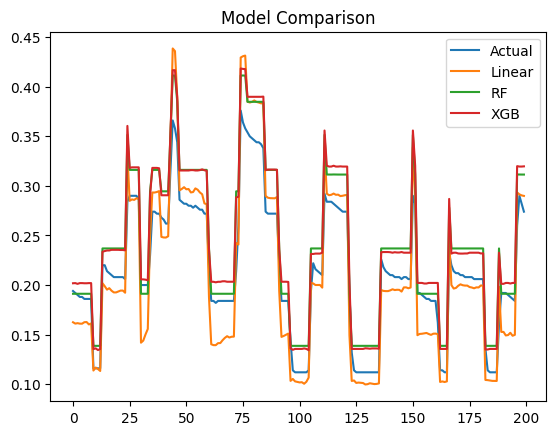

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred_lr[:200], label="Linear")
plt.plot(y_pred_rf[:200], label="RF")
plt.plot(y_pred_xgb[:200], label="XGB")

plt.legend()
plt.title("Model Comparison")
plt.show()

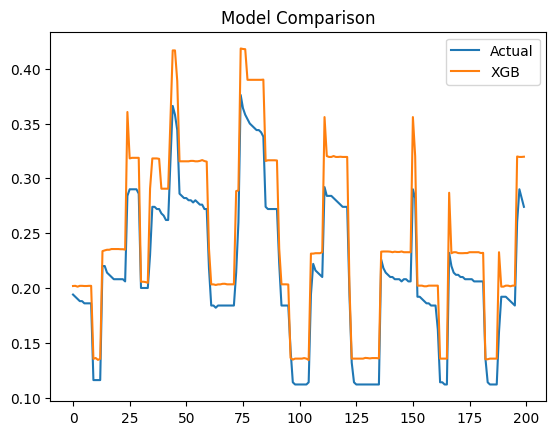

In [ ]:
plt.figure()
plt.plot(y_test.values[:200], label="Actual")

#plt.plot(y_pred_rf[:200], label="RF")
plt.plot(y_pred_xgb[:200], label="XGB")

plt.legend()
plt.title("Model Comparison")
plt.show()

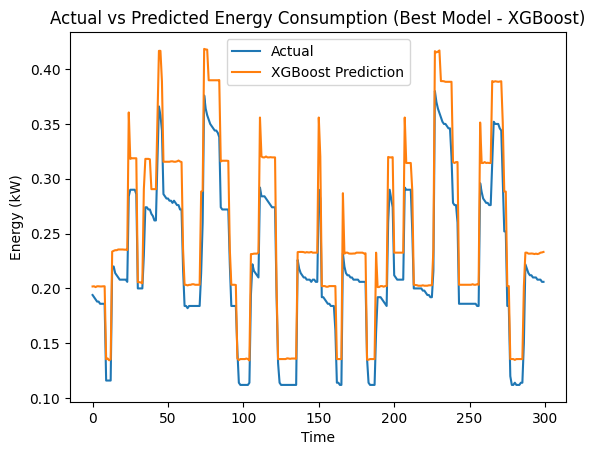

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred_xgb[:300], label="XGBoost Prediction")

plt.legend()
plt.title("Actual vs Predicted Energy Consumption (Best Model - XGBoost)")
plt.xlabel("Time")
plt.ylabel("Energy (kW)")

plt.show()

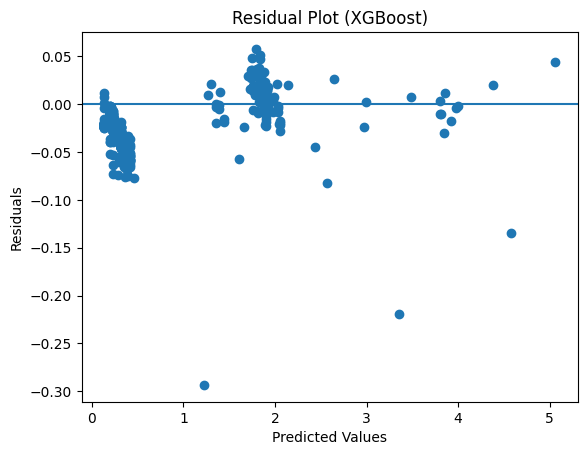

In [ ]:
residuals = y_test[:500] - y_pred_xgb[:500]

plt.figure()
plt.scatter(y_pred_xgb[:500], residuals)

plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (XGBoost)")

plt.show()

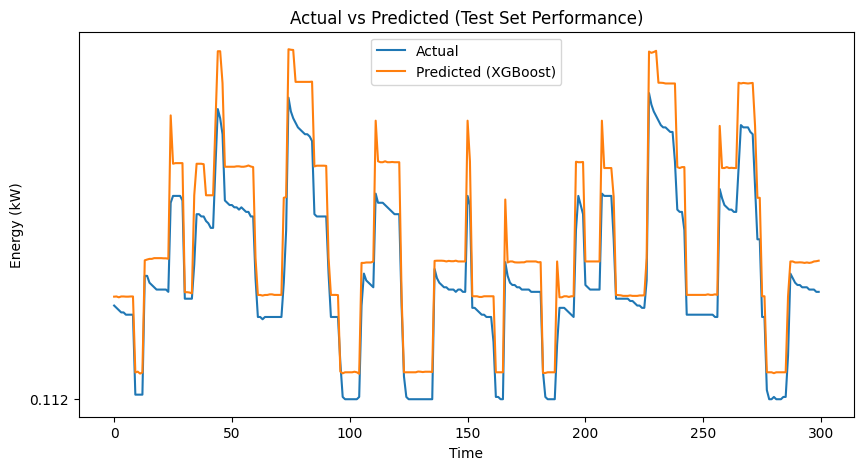

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

# Plot
plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred_xgb[:300], label="Predicted (XGBoost)")

# Labels
plt.xlabel("Time")
plt.ylabel("Energy (kW)")
plt.title("Actual vs Predicted (Test Set Performance)")

# Set Y-axis ticks with step = 0.025
y_min = min(min(y_test.values[:300]), min(y_pred_xgb[:300]))
y_max = max(max(y_test.values[:300]), max(y_pred_xgb[:300]))

plt.yticks(np.arange(y_min, y_max, 0.5))

# Legend
plt.legend()

plt.show()

SHAP Interpretation

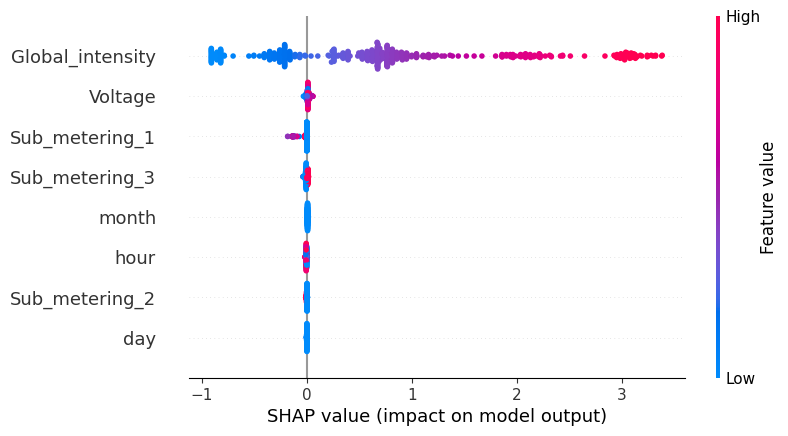

In [ ]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:500])

shap.plots.beeswarm(shap_values)

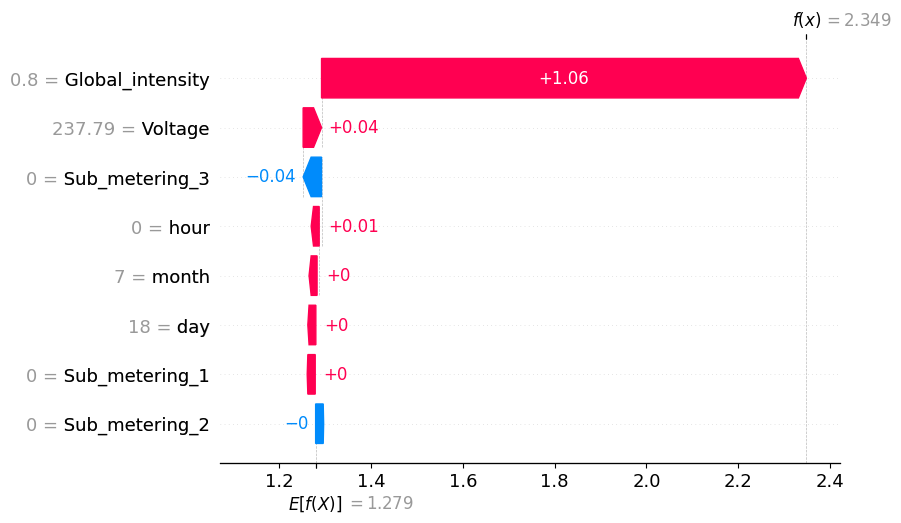

In [ ]:
import shap
import numpy as np

# SHAP Waterfall Plot
explainer = shap.Explainer(best_xgb)
# Select one instance from test set
sample_index = 0

X_sample = X_test.iloc[[sample_index]]
shap_values = explainer(X_sample)
shap.plots.waterfall(shap_values[0])

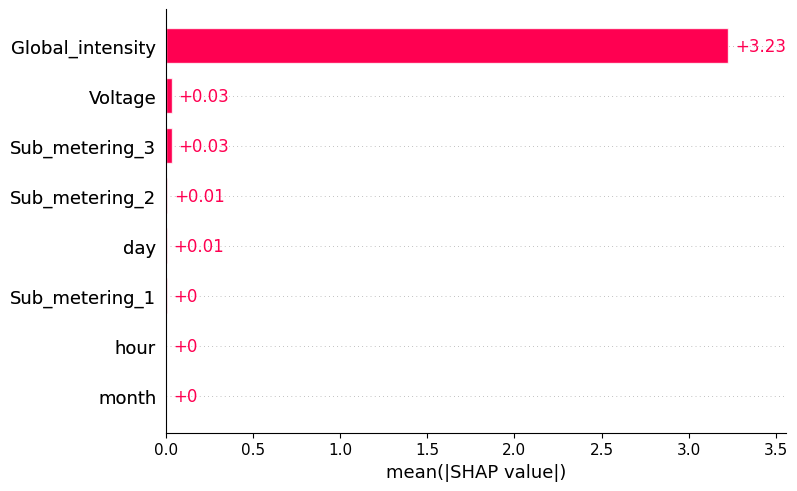

In [ ]:
import shap
import matplotlib.pyplot as plt
# SHAP bar plot

# Create SHAP explainer
explainer = shap.Explainer(best_xgb)

# Compute SHAP values
shap_values = explainer(X_test)

# Plot bar graph
shap.plots.bar(shap_values)

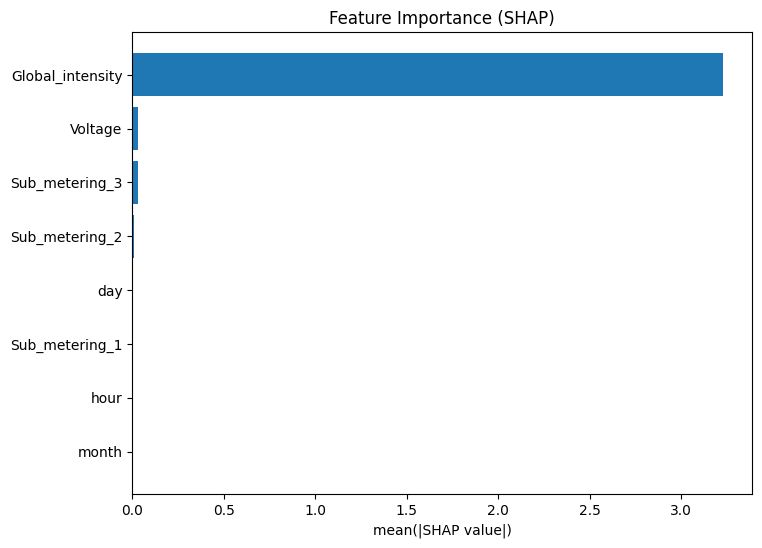

In [ ]:
import numpy as np
import pandas as pd

# Mean absolute SHAP values
mean_shap = np.abs(shap_values.values).mean(axis=0)

# Create DataFrame
shap_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": mean_shap
})

# Sort
shap_df = shap_df.sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(8,6))
plt.barh(shap_df["Feature"], shap_df["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("mean(|SHAP value|)")
plt.title("Feature Importance (SHAP)")

plt.show()

Peak Load Simulation

<Figure size 640x480 with 0 Axes>

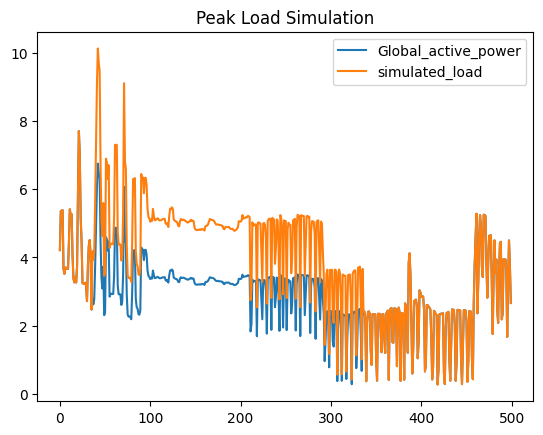

In [ ]:
df_sim = df.copy()

# Simulate peak condition (increase load artificially)
df_sim['simulated_load'] = df_sim['Global_active_power'] * np.where(df_sim['hour'].between(18,22), 1.5, 1)

plt.figure()
df_sim[['Global_active_power','simulated_load']].head(500).plot()
plt.title("Peak Load Simulation")
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

scaled_series = StandardScaler().fit_transform(y.values.reshape(-1,1))

X_seq, y_seq = create_sequences(scaled_series, 10)

split_seq = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]

In [ ]:
# Build LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(50, input_shape=(X_train_seq.shape[1],1)))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
30442/30442 ━━━━━━━━━━━━━━━━━━━━ 264s 9ms/step - loss: 0.0619
Epoch 2/5
30442/30442 ━━━━━━━━━━━━━━━━━━━━ 272s 7ms/step - loss: 0.0561
Epoch 3/5
30442/30442 ━━━━━━━━━━━━━━━━━━━━ 212s 7ms/step - loss: 0.0546
Epoch 4/5
30442/30442 ━━━━━━━━━━━━━━━━━━━━ 270s 7ms/step - loss: 0.0536
Epoch 5/5
30442/30442 ━━━━━━━━━━━━━━━━━━━━ 215s 7ms/step - loss: 0.0529


In [ ]:
y_pred_lstm = model_lstm.predict(X_test_seq)

# Rescale back
scaler_y = StandardScaler()
scaler_y.fit(y.values.reshape(-1,1))

y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm)
y_test_lstm = scaler_y.inverse_transform(y_test_seq)

7611/7611 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step
